In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

df = pd.read_csv(
    "../data/processed/tourism_weather_clean.csv"
)

df["date"] = pd.to_datetime(df["date"])

thai_font = font_manager.FontProperties(
    fname=r"C:\Windows\Fonts\tahoma.ttf"
)

df.head()

,fiscal_year_be,park_name_x,office,month_th,visitors,month_num,calendar_year_be,calendar_year_ce,date,park_key,park_key_final,park_name_y,min_rain,max_rain,avg_rain
0,2561,กุยบุรี,สำนักบริหารพื้นที่อนุรักษ์ที่ 3 สาขาเพชรบุรี,ม.ค.,2199,1,2561,2018,2018-01-01,กุยบุรี,กุยบุรี,กุยบุรี,14.5,54.709999,28.620681
1,2561,ขุนขาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 16,ม.ค.,16242,1,2561,2018,2018-01-01,ขุนขาน,ขุนขาน,ขุนขาน,0.3,30.400000,6.695410
2,2561,ขุนน่าน,สำนักบริหารพื้นที่อนุรักษ์ที่ 13,ม.ค.,523,1,2561,2018,2018-01-01,ขุนน่าน,ขุนน่าน,ขุนน่าน,11.4,30.780001,17.231855
3,2561,ขุนพะวอ,สำนักบริหารพื้นที่อนุรักษ์ที่ 14,ม.ค.,521,1,2561,2018,2018-01-01,ขุนพะวอ,ขุนพะวอ,ขุนพะวอ,0.0,32.000000,9.917311
4,2561,ขุนสถาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 13,ม.ค.,9956,1,2561,2018,2018-01-01,ขุนสถาน,ขุนสถาน,ขุนสถาน,11.4,30.780001,17.231855


Analysis 1. ความสัมพันธ์ระหว่างปริมาณฝนและจำนวนผู้เข้าชม

วิเคราะห์ว่าปริมาณฝนเฉลี่ยรายเดือนมีความสัมพันธ์กับจำนวนผู้เข้าชมอุทยานหรือไม่
โดยใช้ Correlation และ Scatter Plot

Correlation ระหว่างปริมาณฝนกับจำนวนผู้เข้าชม:
-0.08


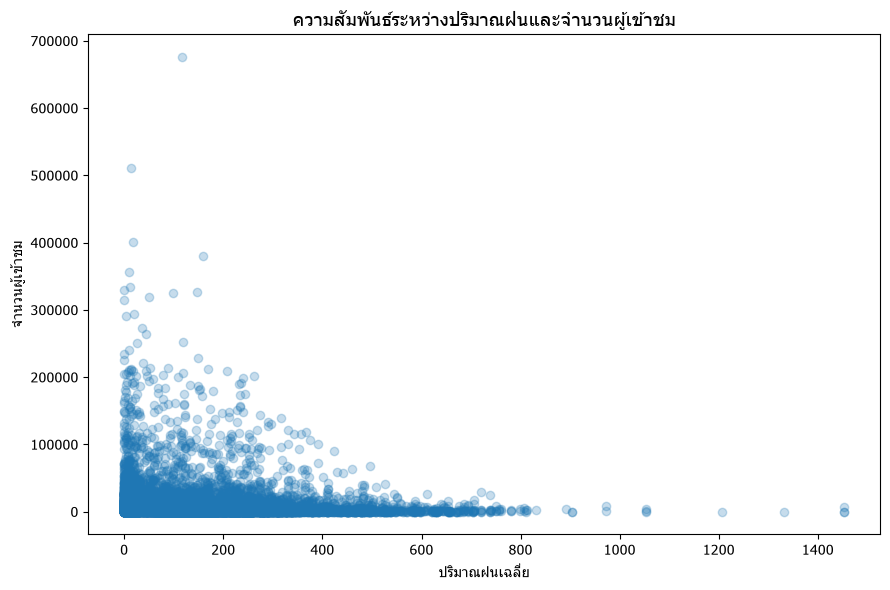

In [2]:
# คำนวณ Correlation
correlation = df["avg_rain"].corr(df["visitors"])

print("Correlation ระหว่างปริมาณฝนกับจำนวนผู้เข้าชม:")
print(round(correlation, 3))


# สร้าง Scatter Plot
plt.figure(figsize=(9, 6))

plt.scatter(
    df["avg_rain"],
    df["visitors"],
    alpha=0.25
)

plt.title(
    "ความสัมพันธ์ระหว่างปริมาณฝนและจำนวนผู้เข้าชม",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel(
    "ปริมาณฝนเฉลี่ย",
    fontproperties=thai_font
)

plt.ylabel(
    "จำนวนผู้เข้าชม",
    fontproperties=thai_font
)

plt.xticks(fontproperties=thai_font)
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

2. รูปแบบปริมาณฝนและจำนวนผู้เข้าชมตามเดือน

เปรียบเทียบค่าเฉลี่ยปริมาณฝนและจำนวนผู้เข้าชมในแต่ละเดือน
เพื่อดูความสัมพันธ์ของฤดูกาลฝนกับรูปแบบการท่องเที่ยวอุทยานแห่งชาติ

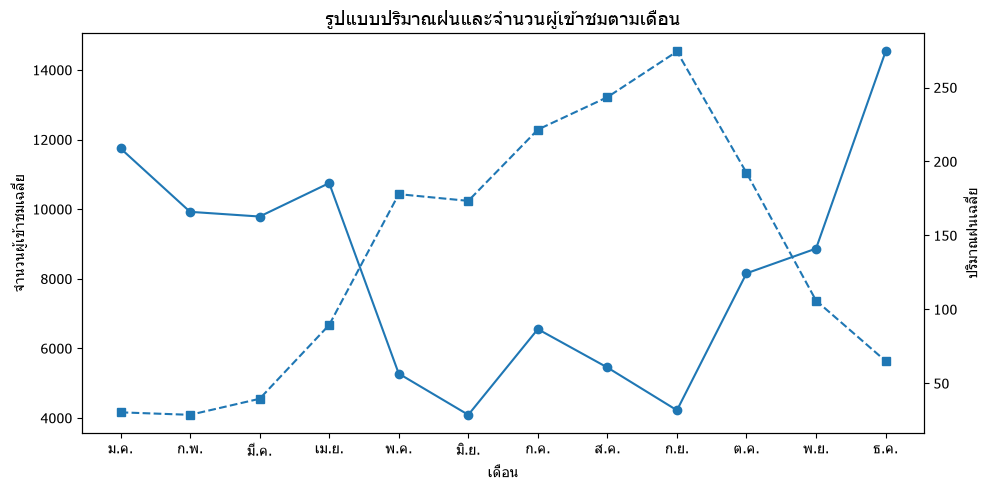

,month_num,month_th,avg_visitors,avg_rain
0,1,ม.ค.,11745.943831,30.365676
1,2,ก.พ.,9923.068140,28.689938
2,3,มี.ค.,9788.032228,39.534374
3,4,เม.ย.,10748.665746,89.455920
4,5,พ.ค.,5273.804788,177.883317
5,6,มิ.ย.,4089.793738,173.350148
6,7,ก.ค.,6551.834254,221.548169
7,8,ส.ค.,5449.656538,243.469985
8,9,ก.ย.,4220.414365,274.343336
9,10,ต.ค.,8156.325667,192.327591


In [3]:
# ใช้เฉพาะปีปฏิทินที่มีข้อมูลครบทั้งปี
monthly_df = df[
    df["calendar_year_ce"].between(2018, 2024)
].copy()

# หาค่าเฉลี่ยของแต่ละเดือน
monthly_pattern = (
    monthly_df
    .groupby(["month_num", "month_th"])
    .agg(
        avg_visitors=("visitors", "mean"),
        avg_rain=("avg_rain", "mean")
    )
    .reset_index()
    .sort_values("month_num")
)

# สร้างกราฟ
fig, ax1 = plt.subplots(figsize=(10, 5))

# จำนวนผู้เข้าชม
ax1.plot(
    monthly_pattern["month_th"],
    monthly_pattern["avg_visitors"],
    marker="o"
)

ax1.set_xlabel(
    "เดือน",
    fontproperties=thai_font
)

ax1.set_ylabel(
    "จำนวนผู้เข้าชมเฉลี่ย",
    fontproperties=thai_font
)

# ปริมาณฝน
ax2 = ax1.twinx()

ax2.plot(
    monthly_pattern["month_th"],
    monthly_pattern["avg_rain"],
    marker="s",
    linestyle="--"
)

ax2.set_ylabel(
    "ปริมาณฝนเฉลี่ย",
    fontproperties=thai_font
)

plt.title(
    "รูปแบบปริมาณฝนและจำนวนผู้เข้าชมตามเดือน",
    fontproperties=thai_font,
    fontsize=14
)

ax1.set_xticks(range(len(monthly_pattern)))
ax1.set_xticklabels(
    monthly_pattern["month_th"],
    fontproperties=thai_font
)

for label in ax1.get_yticklabels():
    label.set_fontproperties(thai_font)

for label in ax2.get_yticklabels():
    label.set_fontproperties(thai_font)

plt.tight_layout()
plt.show()

monthly_pattern

 3. อุทยานที่มีปริมาณฝนน้อยในเดือนที่เลือก

เปรียบเทียบปริมาณฝนเฉลี่ยของแต่ละอุทยานในเดือนที่เลือก
เพื่อค้นหาอุทยานที่มีแนวโน้มเหมาะสำหรับการท่องเที่ยวในช่วงดังกล่าว

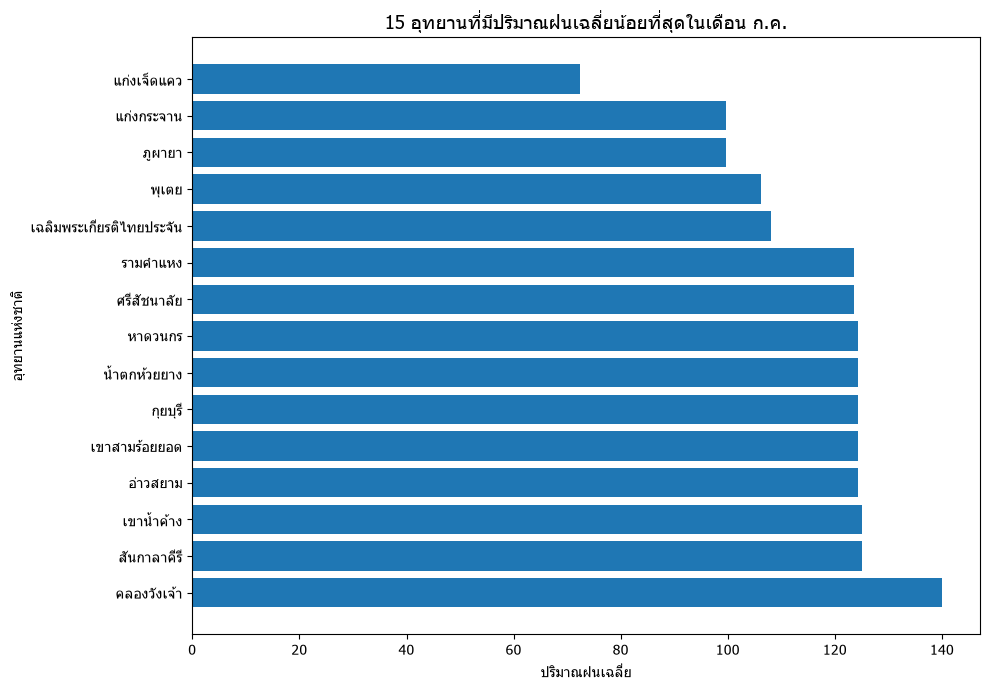

,park_key_final,avg_rain,avg_visitors
139,แก่งเจ็ดแคว,72.411134,42.000000
136,แก่งกระจาน,99.603528,9001.428571
67,ภูผายา,99.727990,753.000000
60,พุเตย,106.149168,954.142857
132,เฉลิมพระเกียรติไทยประจัน,108.140663,5090.571429
81,รามคำแหง,123.626465,2032.000000
90,ศรีสัชนาลัย,123.626465,531.571429
111,อ่าวสยาม,124.268754,1182.142857
123,เขาสามร้อยยอด,124.268754,11852.714286
0,กุยบุรี,124.268754,2171.428571


In [ ]:
selected_month = 7   # แก้ได้ 1=ม.ค. ... 12=ธ.ค.

month_names = {
    1: "ม.ค.", 2: "ก.พ.", 3: "มี.ค.", 4: "เม.ย.",
    5: "พ.ค.", 6: "มิ.ย.", 7: "ก.ค.", 8: "ส.ค.",
    9: "ก.ย.", 10: "ต.ค.", 11: "พ.ย.", 12: "ธ.ค."
}

# ใช้ปีเต็ม 2018-2024
selected_month_data = df[
    (df["calendar_year_ce"].between(2018, 2024)) &
    (df["month_num"] == selected_month)
].copy()

park_month_summary = (
    selected_month_data
    .groupby("park_key_final")
    .agg(
        avg_rain=("avg_rain", "mean"),
        avg_visitors=("visitors", "mean")
    )
    .reset_index()
    .sort_values("avg_rain")
)

# 15 อุทยานที่ฝนน้อยที่สุด
lowest_rain_parks = park_month_summary.head(15)

# กราฟ
plot_data = lowest_rain_parks.sort_values("avg_rain", ascending=False)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["park_key_final"],
    plot_data["avg_rain"]
)

plt.title(
    f"15 อุทยานที่มีปริมาณฝนเฉลี่ยน้อยที่สุดในเดือน {month_names[selected_month]}",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel(
    "ปริมาณฝนเฉลี่ย",
    fontproperties=thai_font
)

plt.ylabel(
    "อุทยานแห่งชาติ",
    fontproperties=thai_font
)

plt.xticks(fontproperties=thai_font)
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

lowest_rain_parks

4. จัดอันดับอุทยานจากฝนและจำนวนผู้เข้าชม

สร้างคะแนนเบื้องต้นจากปริมาณฝนและจำนวนผู้เข้าชมเฉลี่ย
เพื่อค้นหาอุทยานที่มีฝนน้อยและมีความหนาแน่นของนักท่องเที่ยวต่ำ
ในเดือนที่เลือก

คะแนนนี้เป็นการวิเคราะห์เบื้องต้น และยังไม่รวมข้อมูลการเปิด-ปิดอุทยาน

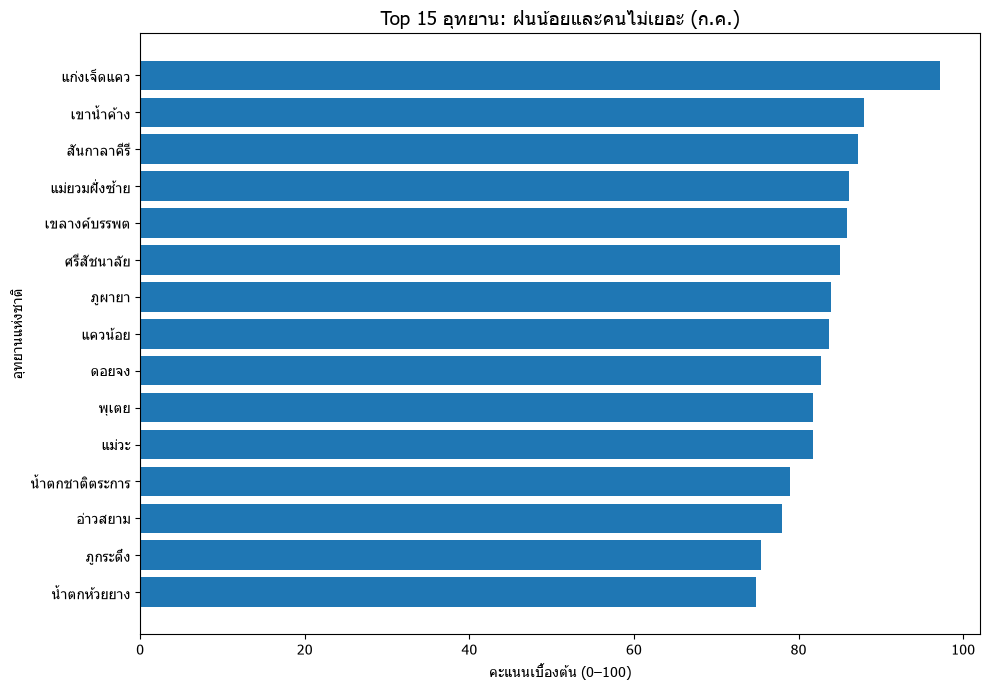

,park_key_final,avg_rain,avg_visitors,preliminary_score
139,แก่งเจ็ดแคว,72.411134,42.000000,97.169811
117,เขาน้ำค้าง,125.012329,272.000000,87.893082
91,สันกาลาคีรี,125.012329,287.428571,87.264151
147,แม่ยวมฝั่งซ้าย,163.237419,21.000000,86.163522
112,เขลางค์บรรพต,149.142854,183.714286,85.849057
90,ศรีสัชนาลัย,123.626465,531.571429,85.062893
67,ภูผายา,99.727990,753.000000,83.962264
140,แควน้อย,153.015389,207.166667,83.647799
10,ดอยจง,149.142854,316.857143,82.704403
60,พุเตย,106.149168,954.142857,81.761006


In [5]:
selected_month = 7   # 1=ม.ค. ... 12=ธ.ค.

month_names = {
    1: "ม.ค.", 2: "ก.พ.", 3: "มี.ค.", 4: "เม.ย.",
    5: "พ.ค.", 6: "มิ.ย.", 7: "ก.ค.", 8: "ส.ค.",
    9: "ก.ย.", 10: "ต.ค.", 11: "พ.ย.", 12: "ธ.ค."
}

# ใช้เฉพาะปีเต็ม
month_data = df[
    (df["calendar_year_ce"].between(2018, 2024)) &
    (df["month_num"] == selected_month)
].copy()

# ค่าเฉลี่ยของแต่ละอุทยาน
park_score = (
    month_data
    .groupby("park_key_final")
    .agg(
        avg_rain=("avg_rain", "mean"),
        avg_visitors=("visitors", "mean")
    )
    .reset_index()
)

# ฝนน้อย = คะแนนสูง
park_score["rain_score"] = (
    1 - park_score["avg_rain"].rank(pct=True)
)

# คนน้อย = คะแนนสูง
park_score["crowd_score"] = (
    1 - park_score["avg_visitors"].rank(pct=True)
)

# คะแนนเบื้องต้น 50% ฝน + 50% จำนวนคน
park_score["preliminary_score"] = (
    park_score["rain_score"] * 0.5 +
    park_score["crowd_score"] * 0.5
) * 100

# Top 15
top_candidates = (
    park_score
    .sort_values("preliminary_score", ascending=False)
    .head(15)
)

# สร้างกราฟ
plot_data = top_candidates.sort_values("preliminary_score")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["park_key_final"],
    plot_data["preliminary_score"]
)

plt.title(
    f"Top 15 อุทยาน: ฝนน้อยและคนไม่เยอะ ({month_names[selected_month]})",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel(
    "คะแนนเบื้องต้น (0–100)",
    fontproperties=thai_font
)

plt.ylabel(
    "อุทยานแห่งชาติ",
    fontproperties=thai_font
)

plt.xticks(fontproperties=thai_font)
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

top_candidates[
    [
        "park_key_final",
        "avg_rain",
        "avg_visitors",
        "preliminary_score"
    ]
]